## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from tigramite import data_processing as pp
from tigramite import plotting as tp
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb
from tigramite.independence_tests.gpdc_torch import GPDCtorch
from tigramite.independence_tests.gsquared import Gsquared
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.robust_parcorr import RobustParCorr
from tigramite.lpcmci import LPCMCI

from csi_vae_gumbel.settings import Settings

IND_TEST = "gpdc"
DEBUG = True
SAVE_FIGS = True
FILTER_THRESHOLD = 0.2

In [2]:
settings = Settings()

is_ind_test_categorical = IND_TEST in ["cmiknn", "gsquared", "cmisymb"]

match IND_TEST:
    case "parcorr":
        ind_test = ParCorr(significance="analytic")
    case "robustparcorr":
        ind_test = RobustParCorr(significance="analytic")
    case "gpdc":
        ind_test = GPDCtorch()
    case "gsquared":
        ind_test = Gsquared()
    case "cmisymb":
        ind_test = CMIsymb()
    case "cmiknn":
        ind_test = CMIknn()
    case _:
        msg = f"Unknown independence test: {IND_TEST}"
        raise ValueError(msg)

## Dataset

We use the complete dataset for causal inference, withouy any train/test split.

In [3]:
# Shape will be (T, latent_dim, n_categories)
latents_raw = np.load(f"../{settings.study_path}/latents/latents_{'hard' if is_ind_test_categorical else 'soft'}.npy")

# Shape will be (T,)
labels = np.load(f"../{settings.study_path}/latents/labels.npy")

if is_ind_test_categorical:
    # Get the argmax indices (the most likely category) for each latent dimension
    latents = np.argmax(latents_raw, axis=2)
else:
    # Get the probability of the most likely category for each latent dimension
    latents = torch.softmax(torch.from_numpy(latents_raw), dim=2).numpy()
    latents = np.max(latents, axis=2)

labelled_causal_data = {}

# 2. Split and THEN shift per activity
for label in np.unique(labels):
    # Extract latents for this specific movement sequence
    activity_latents = latents[labels == label]
    activity_latents = activity_latents[::settings.train_window_size]
    labelled_causal_data[int(label)] = activity_latents

## Causal Analysis


Starting preliminary phase  1

Starting test phase

p = 0
(0,-5) independent (0, 0) given () union set()
(0,-3) independent (0, 0) given () union set()
(0,-1) independent (0, 0) given () union set()
(2,-5) independent (2, 0) given () union set()
(2,-3) independent (2, 0) given () union set()
(2,-1) independent (2, 0) given () union set()
(3,-5) independent (3, 0) given () union set()
(3,-3) independent (3, 0) given () union set()
(3,-1) independent (3, 0) given () union set()
(4,-5) independent (4, 0) given () union set()
(4,-3) independent (4, 0) given () union set()
(4,-1) independent (4, 0) given () union set()
(5,-5) independent (5, 0) given () union set()
(5,-3) independent (5, 0) given () union set()
(5,-1) independent (5, 0) given () union set()
Writing:   (0,-5) oL> (0, 0) ==> (0,-5)     (0, 0) 
Writing:   (0,-3) oL> (0, 0) ==> (0,-3)     (0, 0) 
Writing:   (0,-1) oL> (0, 0) ==> (0,-1)     (0, 0) 
Writing:   (2,-5) oL> (2, 0) ==> (2,-5)     (2, 0) 
Writing:   (2,-3) oL> (2, 0)

/mnt/servicesdata/lcotti/csi-vae-gumbel/.venv/lib/python3.13/site-packages/torch/nn/parallel/data_parallel.py:45: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  if warn_imbalance(lambda props: props.total_memory):
/mnt/servicesdata/lcotti/csi-vae-gumbel/.venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


(0,-4) independent (0, 0) given ((5, -4),) union set()
(1,-5) independent (1, 0) given ((4, -2),) union set()
(1,-3) independent (1, 0) given ((0, -2),) union set()
(2,-4) independent (2, 0) given ((2, -2),) union set()
(4,-4) independent (4, 0) given ((4, -2),) union set()
Writing:   (0,-4) oL> (0, 0) ==> (0,-4)     (0, 0) 
Writing:   (1,-5) oL> (1, 0) ==> (1,-5)     (1, 0) 
Writing:   (1,-3) oL> (1, 0) ==> (1,-3)     (1, 0) 
Writing:   (2,-4) oL> (2, 0) ==> (2,-4)     (2, 0) 
Writing:   (4,-4) oL> (4, 0) ==> (4,-4)     (4, 0) 
(0,-1) independent (1, 0) given ((0, -2),) union set()
(0,-1) independent (2, 0) given ((2, -2),) union set()
(1,-1) independent (0, 0) given ((5, -2),) union set()
(1,-1) independent (2, 0) given ((2, -2),) union set()
(1,-1) independent (4, 0) given ((4, -2),) union set()
(1,-1) independent (5, 0) given ((5, -2),) union set()
(2,-1) independent (0, 0) given ((0, -2),) union set()
(2,-1) independent (1, 0) given ((1, -2),) union set()
(2,-1) independent (4, 0)

/mnt/servicesdata/lcotti/csi-vae-gumbel/.venv/lib/python3.13/site-packages/linear_operator/utils/linear_cg.py:338: NumericalWarning: CG terminated in 1000 iterations with average residual norm 1.1496155261993408 which is larger than the tolerance of 1 specified by linear_operator.settings.cg_tolerance. If performance is affected, consider raising the maximum number of CG iterations by running code in a linear_operator.settings.max_cg_iterations(value) context.
  warnings.warn(


(1,-2) independent (3, 0) given ((2, -2),) union {(5, -2), (3, -2)}
Writing:   (1,-2) oL> (3, 0) ==> (1,-2)     (3, 0) 

Test phase complete

Starting orientation phase
with rule list:  [['APR'], ['ER-08'], ['ER-02'], ['ER-01'], ['ER-09'], ['ER-10']]

APR:
Found nothing

ER-08:
Found nothing

ER-02:
Found nothing

ER-01:
Found nothing

ER-09:
Found nothing

ER-10:
Found nothing

Orientation phase complete
p = 2
(1,-1) independent (1, 0) given ((1, -2), (1, -4)) union set()
Writing:   (2,-2) -L> (2, 0) ==> (2,-2) -!> (2, 0) 
Writing:   (1,-1) oL> (1, 0) ==> (1,-1)     (1, 0) 
(0,-2) independent (1, 0) given ((1, -2), (1, -4)) union {(0, -4)}
Writing:   (0,-2) -L> (2, 0) ==> (0,-2) -!> (2, 0) 
Writing:   (2,-2) oL> (3, 0) ==> (2,-2) o!> (3, 0) 
(4,-2) independent (1, 0) given ((1, -2), (0, -2)) union {(3, -4), (4, -4)}
Writing:   (0,-2) oL> (1, 0) ==> (0,-2)     (1, 0) 
Writing:   (4,-2) oL> (1, 0) ==> (4,-2)     (1, 0) 
Writing:   (1,-4) oL> (5, 0) ==> (1,-4) o!> (5, 0) 
(3,-4) independ

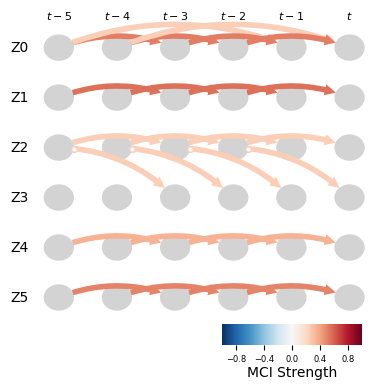


Starting preliminary phase  1

Starting test phase

p = 0
(0,-5) independent (0, 0) given () union set()
(0,-3) independent (0, 0) given () union set()
(2,-5) independent (2, 0) given () union set()
(2,-3) independent (2, 0) given () union set()
(2,-1) independent (2, 0) given () union set()
(3,-5) independent (3, 0) given () union set()
(3,-3) independent (3, 0) given () union set()
(3,-1) independent (3, 0) given () union set()
(4,-5) independent (4, 0) given () union set()
(4,-3) independent (4, 0) given () union set()
(5,-5) independent (5, 0) given () union set()
(5,-3) independent (5, 0) given () union set()
Writing:   (0,-5) oL> (0, 0) ==> (0,-5)     (0, 0) 
Writing:   (0,-3) oL> (0, 0) ==> (0,-3)     (0, 0) 
Writing:   (2,-5) oL> (2, 0) ==> (2,-5)     (2, 0) 
Writing:   (2,-3) oL> (2, 0) ==> (2,-3)     (2, 0) 
Writing:   (2,-1) oL> (2, 0) ==> (2,-1)     (2, 0) 
Writing:   (3,-5) oL> (3, 0) ==> (3,-5)     (3, 0) 
Writing:   (3,-3) oL> (3, 0) ==> (3,-3)     (3, 0) 
Writing:   (3

/mnt/servicesdata/lcotti/csi-vae-gumbel/.venv/lib/python3.13/site-packages/torch/nn/parallel/data_parallel.py:45: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  if warn_imbalance(lambda props: props.total_memory):
/mnt/servicesdata/lcotti/csi-vae-gumbel/.venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


(0,-4) independent (0, 0) given ((4, -2),) union set()
(0,-1) independent (0, 0) given ((4, -2),) union set()
(1,-5) independent (1, 0) given ((1, -2),) union set()
(1,-3) independent (1, 0) given ((1, -2),) union set()
(2,-4) independent (2, 0) given ((5, -4),) union set()
(3,-2) independent (3, 0) given ((5, -2),) union set()
(4,-4) independent (4, 0) given ((1, -4),) union set()
(4,-1) independent (4, 0) given ((1, -2),) union set()
(5,-1) independent (5, 0) given ((5, -2),) union set()
Writing:   (0,-4) oL> (0, 0) ==> (0,-4)     (0, 0) 
Writing:   (0,-1) oL> (0, 0) ==> (0,-1)     (0, 0) 
Writing:   (1,-5) oL> (1, 0) ==> (1,-5)     (1, 0) 
Writing:   (1,-3) oL> (1, 0) ==> (1,-3)     (1, 0) 
Writing:   (2,-4) oL> (2, 0) ==> (2,-4)     (2, 0) 
Writing:   (3,-2) oL> (3, 0) ==> (3,-2)     (3, 0) 
Writing:   (4,-4) oL> (4, 0) ==> (4,-4)     (4, 0) 
Writing:   (4,-1) oL> (4, 0) ==> (4,-1)     (4, 0) 
Writing:   (5,-1) oL> (5, 0) ==> (5,-1)     (5, 0) 
(0,-1) independent (1, 0) given ((0, 

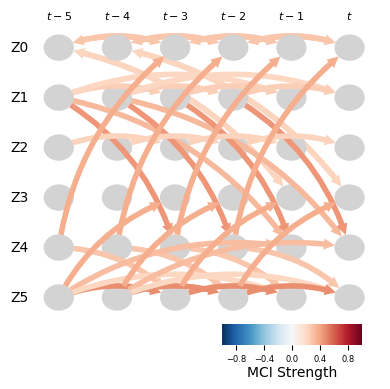


Starting preliminary phase  1

Starting test phase

p = 0
(5,-5) independent (5, 0) given () union set()
Writing:   (5,-5) oL> (5, 0) ==> (5,-5)     (5, 0) 
(0,-1) independent (5, 0) given () union set()
(2,-1) independent (5, 0) given () union set()
(5,-1) independent (0, 0) given () union set()
(5,-1) independent (2, 0) given () union set()
Writing:   (5,-1) oL> (0, 0) ==> (5,-1)     (0, 0) 
Writing:   (5,-1) oL> (2, 0) ==> (5,-1)     (2, 0) 
Writing:   (0,-1) oL> (5, 0) ==> (0,-1)     (5, 0) 
Writing:   (2,-1) oL> (5, 0) ==> (2,-1)     (5, 0) 
(5,-2) independent (0, 0) given () union set()
(5,-2) independent (3, 0) given () union set()
(5,-2) independent (4, 0) given () union set()
Writing:   (5,-2) oL> (0, 0) ==> (5,-2)     (0, 0) 
Writing:   (5,-2) oL> (3, 0) ==> (5,-2)     (3, 0) 
Writing:   (5,-2) oL> (4, 0) ==> (5,-2)     (4, 0) 
(2,-3) independent (5, 0) given () union set()
(3,-3) independent (5, 0) given () union set()
(5,-3) independent (0, 0) given () union set()
(5,-3) i

/mnt/servicesdata/lcotti/csi-vae-gumbel/.venv/lib/python3.13/site-packages/torch/nn/parallel/data_parallel.py:45: UserWarning: 
    There is an imbalance between your GPUs. You may want to exclude GPU 1 which
    has less than 75% of the memory or cores of GPU 0. You can do so by setting
    the device_ids argument to DataParallel, or by setting the CUDA_VISIBLE_DEVICES
    environment variable.
  if warn_imbalance(lambda props: props.total_memory):
/mnt/servicesdata/lcotti/csi-vae-gumbel/.venv/lib/python3.13/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


(0,-1) independent (0, 0) given ((0, -3),) union set()
(2,-5) independent (2, 0) given ((2, -2),) union set()
(2,-3) independent (2, 0) given ((0, -2),) union set()
(2,-1) independent (2, 0) given ((2, -2),) union set()
(3,-5) independent (3, 0) given ((0, -4),) union set()
(3,-4) independent (3, 0) given ((0, -4),) union set()


KeyboardInterrupt: 

In [4]:
var_names = [f"Z{i}" for i in range(latents.shape[1])]

# 2. Iterate through each activity
for label_id, data in labelled_causal_data.items():
    activity_name = settings.activities[label_id]

    # Initialize Tigramite DataFrame
    # Note: 'datatypes' should be 'discrete' for Gsquared
    data_type = np.ones_like(data) if is_ind_test_categorical else np.zeros_like(data)
    dataframe = pp.DataFrame(data, var_names=var_names, data_type=data_type)

    # 3. Run LPCMCI
    # LPCMCI is robust to latent common causes (unobserved drivers in CSI)
    lpcmci = LPCMCI(dataframe=dataframe, cond_ind_test=ind_test, verbosity=DEBUG)

    # pc_alpha is the significance level for the conditional independence tests
    results = lpcmci.run_lpcmci(
        tau_min=1,
        tau_max=settings.test_window_ratio - 1,
        pc_alpha=1e-3,
    )

    # Create copies so you don't mutate the original results
    filtered_val_matrix = results["val_matrix"].copy()
    filtered_graph = results["graph"].copy()

    # Find indices where the absolute strength is below the threshold and zero them
    weak_links = np.abs(filtered_val_matrix) < FILTER_THRESHOLD
    filtered_val_matrix[weak_links] = 0
    filtered_graph[weak_links] = ""

    print(activity_name)

    # 4. Plotting
    # Time series graph is best for t, t-1, t-2 visualization
    fig, ax = tp.plot_time_series_graph(
        figsize=(4, 4),
        val_matrix=filtered_val_matrix,
        graph=filtered_graph,
        var_names=var_names,
        link_colorbar_label="MCI Strength",
    )

    plt.tight_layout()

    if SAVE_FIGS:
        out_dir = Path(f"../{settings.study_path}/causal_analysis/{IND_TEST}")
        out_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_dir / f"{activity_name}.pdf")

    plt.show()